# TAE-IA · Module 6 · L05 — ControlNet: Structure-Guided Generation

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L05 |
| **Track** | A — Vision |
| **Estimated duration** | 2 hours |
| **GPU required** | T4 (Colab) |
| **Prerequisites** | L01–L04 completed; L04 cleanup cell run |

## Learning objectives
By the end of this notebook you will be able to:
- [ ] Explain how ControlNet injects conditioning signals into the UNet without modifying its frozen weights
- [ ] Extract Canny edges and depth maps as conditioning inputs
- [ ] Use `StableDiffusionControlNetPipeline` with Canny and depth conditioners
- [ ] Tune `controlnet_conditioning_scale` and explain its effect

## Before you start
- L04 cleanup cell must have been run — frees Drive space for this lab's models
- T4 GPU runtime selected (`Runtime > Change runtime type > T4 GPU`)

---

## Cell 0 — Setup (always run this first)

> Mounts Drive, checks GPU, fixes seed, and logs in to HuggingFace.

In [18]:
# ================================================================
# TAE-IA M6 · Standard Setup -- DO NOT MODIFY THIS CELL
# ================================================================
import os, sys, random, shutil
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

MODEL_CACHE = '/content/drive/MyDrive/TAE_IA_M6/models'
os.makedirs(MODEL_CACHE, exist_ok=True)
print(f'Model cache: {MODEL_CACHE}')

# Clear any cache left by earlier course versions.
for _leftover in ('hub', 'xet'):
    _p = os.path.join(MODEL_CACHE, _leftover)
    if os.path.exists(_p):
        shutil.rmtree(_p)

import torch
if not torch.cuda.is_available():
    print('\nNo GPU detected. Go to: Runtime > Change runtime type > T4 GPU')
    raise SystemExit('GPU required.')

gpu_name = torch.cuda.get_device_name(0)
vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'GPU: {gpu_name}  |  VRAM: {vram_gb:.1f} GB')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
print(f'Fixed seed: {SEED}')
print(f'Python {sys.version.split()[0]}  |  PyTorch {torch.__version__}')

# HuggingFace login -- needed every new Colab session
import huggingface_hub

try:
    _token = huggingface_hub.get_token()
except Exception:
    _token = None

if _token:
    print(f"Already logged in to HuggingFace as: {huggingface_hub.whoami()['name']}")
else:
    try:
        from google.colab import userdata
        _hf_token = userdata.get('HF_TOKEN')
    except Exception:
        _hf_token = None

    if _hf_token:
        huggingface_hub.login(token=_hf_token, add_to_git_credential=False)
        print(f"Logged in to HuggingFace as: {huggingface_hub.whoami()['name']}")
    else:
        raise RuntimeError(
            'No HF_TOKEN found in Colab Secrets (key icon, left sidebar).\n'
            'Add a secret named HF_TOKEN with your HuggingFace read token, enable notebook access, '
            'then re-run this cell.\n'
            'See L00 Cell 4 if you need to generate a token or accept the SD 1.5 license.'
        )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model cache: /content/drive/MyDrive/TAE_IA_M6/models
GPU: Tesla T4  |  VRAM: 15.6 GB
Fixed seed: 42
Python 3.13.15  |  PyTorch 2.11.0+cu128
Already logged in to HuggingFace as: joalmurilloor


In [19]:
# ================================================================
# Install dependencies for L05
# controlnet-aux provides preprocessing detectors (Canny, MiDaS, etc.)
# ================================================================
!pip install diffusers transformers accelerate controlnet-aux opencv-python-headless -q

import diffusers, controlnet_aux, cv2
print(f'diffusers {diffusers.__version__}  |  controlnet-aux {controlnet_aux.__version__}  |  OpenCV {cv2.__version__}')

diffusers 0.40.0  |  controlnet-aux 0.0.10  |  OpenCV 5.0.0


---
## Part 1 — Context and Key Concepts

> Read this before running any code.

### The problem text prompts cannot solve

Text prompts excel at controlling *what* is in the image and *how it looks* (style, color, mood). They are poor at controlling *where* things are, *how* the camera is positioned, or *what pose* a subject holds. Running the same composition-specific prompt ten times produces ten different layouts.

img2img partially solves this by starting from an existing image, but it requires a near-finished source — a rough sketch or wireframe gives poor results because img2img encodes the *pixels*, not the *structure*.

### ControlNet architecture

ControlNet (Zhang et al., 2023) adds a **trainable copy of the UNet encoder** alongside the frozen SD 1.5 model:

```
Conditioning image (Canny / depth)
    │
    ▼
ControlNet Encoder  ← trainable, initialized from UNet encoder weights
    │  outputs feature maps at each resolution scale
    ▼  added to UNet skip connections and mid block
UNet (frozen SD 1.5)
    │
    ▼
VAE Decoder → output image
```

Because the SD 1.5 weights are frozen, **all of its generation quality is preserved**. ControlNet only adds structural guidance on top.

### `controlnet_conditioning_scale`

This parameter (default `1.0`) controls how strongly the ControlNet signal influences the output:
- `0.5`: soft guidance — model has more creative freedom, structure loosely followed
- `1.0`: balanced — good default for most use cases
- `1.5+`: strict guidance — model rigidly follows the control signal, may reduce image quality

### Canny vs. Depth conditioning

- **Canny edges:** captures object outlines and internal structure. Best when the source has clear, meaningful edges (architecture, mechanical objects, illustrations). Over-sensitive to noise.
- **Depth map:** captures near/far relationships. More robust to texture and noise than Canny. Best for controlling perspective and 3D layout without locking in specific shapes.

Each conditioner requires its own ControlNet checkpoint — they are not interchangeable.

---

## Part 2 — Lab

### Section 2.0 — Load pipeline

Loads SD 1.5 once. Every ControlNet pipeline built later in this lab reuses these same loaded
components instead of reloading the base model from scratch — the original version of this
notebook reloaded SD 1.5 from scratch four separate times.

In [20]:
# Section 2.0 — Load pipeline
from diffusers import StableDiffusionPipeline
from huggingface_hub import snapshot_download
import torch, gc, os, cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def gen(seed=SEED):
    return torch.Generator("cuda").manual_seed(seed)

OUTPUT_DIR = '/content/drive/MyDrive/TAE_IA_M6/L05_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Fetch only the fp16 weights + configs (~2.5 GB) -- shared with L01-L04 if already cached.
SD15_DIR = os.path.join(MODEL_CACHE, 'sd15-local')
snapshot_download(
    "runwayml/stable-diffusion-v1-5",
    local_dir=SD15_DIR,
    allow_patterns=["*.json", "*.txt", "*.fp16.safetensors"],
)

# Loaded once, kept alive for the whole notebook -- every ControlNet pipeline below reuses
# these components instead of reloading SD 1.5 from scratch.
pipe_txt = StableDiffusionPipeline.from_pretrained(
    SD15_DIR,
    torch_dtype=torch.float16,
    variant="fp16",
).to("cuda")
print("txt2img pipeline loaded (stays loaded for the rest of this notebook).")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

txt2img pipeline loaded (stays loaded for the rest of this notebook).


### Section 2.1 — Generate source image and extract Canny edges

  0%|          | 0/25 [00:00<?, ?it/s]

Source generated.
Canny edges extracted.


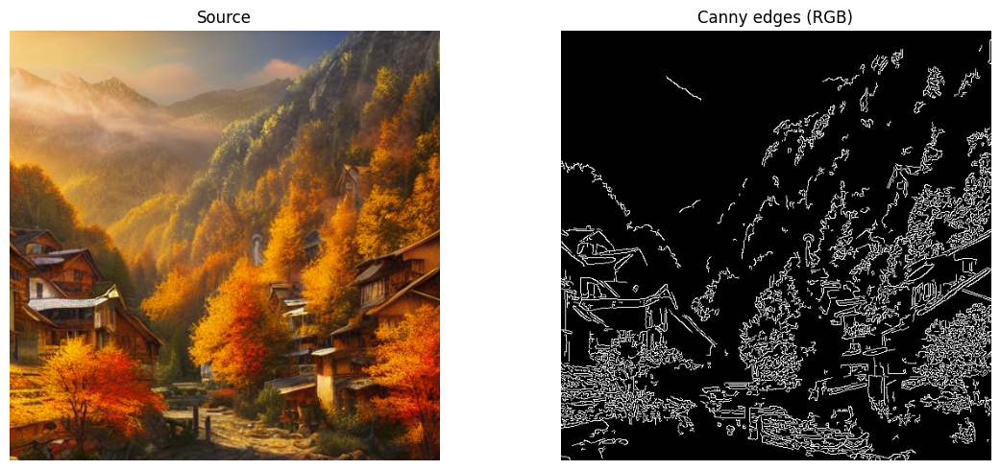

In [5]:
# Section 2.1 — Source image and Canny preprocessing
SOURCE_PROMPT = "a mountain village in autumn, warm golden light, photorealistic, high detail"
source = pipe_txt(
    SOURCE_PROMPT,
    num_inference_steps=25, guidance_scale=7.5, generator=gen()
).images[0]
source = source.resize((512, 512))
source.save(os.path.join(OUTPUT_DIR, "source.png"))
print("Source generated.")

# Extract Canny edges
gray         = np.array(source.convert("L"))
edges        = cv2.Canny(gray, threshold1=100, threshold2=200)
canny_image  = Image.fromarray(edges).convert("RGB")   # ControlNet expects RGB
canny_image.save(os.path.join(OUTPUT_DIR, "canny.png"))
print("Canny edges extracted.")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(source); axes[0].set_title("Source"); axes[0].axis('off')
axes[1].imshow(canny_image); axes[1].set_title("Canny edges (RGB)"); axes[1].axis('off')
plt.tight_layout(); plt.show()

**What do you observe?**  
- Which parts of the image produced the most edges? Which areas are sparse?
- Are there any edges that look like noise rather than real structure?

* **High-Density vs. Sparse Areas:** The foliage of the foreground trees and the architectural contours of the village houses produce the highest concentration of edges due to high local contrast and fine detail. In contrast, the smooth gradient of the sky and the soft, shaded areas of the mountain slopes are sparse, producing virtually no edge signals.

* **Structural Edges vs. Texture Noise:** True structural boundaries—such as the rooflines, windows, and main mountain ridges—are captured as clean, continuous lines. However, the chaotic cluster of edges across the tree leaves represents high-frequency texture noise rather than actual geometric structure, which can cause Canny-based ControlNet to overly lock in leaf patterns instead of focusing solely on object shapes.

### Section 2.2 — Canny ControlNet: style variations preserving composition

Load the Canny ControlNet checkpoint and generate several styles from the same edge map.

In [6]:
# Section 2.2 — Load ControlNet-Canny pipeline
from diffusers import ControlNetModel, StableDiffusionControlNetPipeline
from diffusers import UniPCMultistepScheduler

# This checkpoint doesn't ship an fp16-suffixed variant, only fp32 -- torch_dtype still
# casts it to fp16 in memory. Configs + the one weight format, skip the .bin duplicate.
CANNY_DIR = os.path.join(MODEL_CACHE, 'controlnet-canny-local')
snapshot_download(
    "lllyasviel/sd-controlnet-canny",
    local_dir=CANNY_DIR,
    allow_patterns=["*.json", "*.safetensors"],
)
controlnet_canny = ControlNetModel.from_pretrained(CANNY_DIR, torch_dtype=torch.float16)

# Reuses pipe_txt's already-loaded components -- no second SD 1.5 load from disk.
pipe_canny = StableDiffusionControlNetPipeline(controlnet=controlnet_canny, **pipe_txt.components).to("cuda")
# UniPC needs fewer steps than PNDM — 20 is enough
pipe_canny.scheduler = UniPCMultistepScheduler.from_config(pipe_canny.scheduler.config)
print("ControlNet-Canny pipeline ready.")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

ControlNet-Canny pipeline ready.


  0%|          | 0/20 [00:00<?, ?it/s]

Done: oil painting, impressionist, warm autumn


  0%|          | 0/20 [00:00<?, ?it/s]

Done: watercolor illustration, soft pastels, s


  0%|          | 0/20 [00:00<?, ?it/s]

Done: cyberpunk neon city, rain reflections, n


  0%|          | 0/20 [00:00<?, ?it/s]

Done: pencil sketch, detailed linework, black 


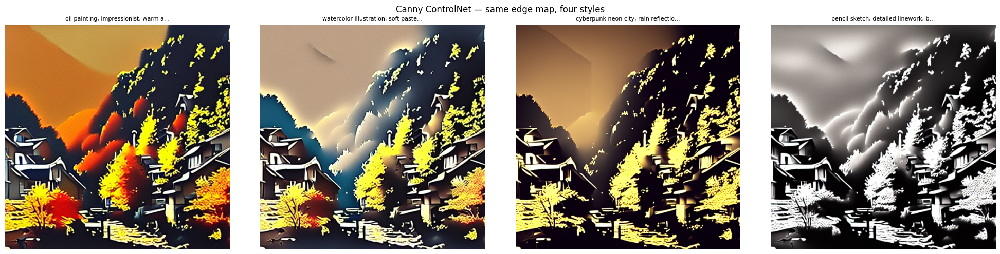

In [7]:
# Section 2.2 — Style variations from the same Canny map
style_prompts = [
    "oil painting, impressionist, warm autumn colors, Van Gogh style",
    "watercolor illustration, soft pastels, storybook art",
    "cyberpunk neon city, rain reflections, night scene",
    "pencil sketch, detailed linework, black and white",
]

canny_results = []
for prompt in style_prompts:
    img = pipe_canny(
        prompt                        = prompt,
        image                         = canny_image,
        controlnet_conditioning_scale = 1.0,
        num_inference_steps           = 20,
        guidance_scale                = 7.5,
        generator                     = gen()
    ).images[0]
    fname = prompt[:30].replace(",", "").replace(" ", "_") + ".png"
    img.save(os.path.join(OUTPUT_DIR, f"canny_{fname}"))
    canny_results.append((prompt[:35] + "...", img))
    print(f"Done: {prompt[:40]}")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (label, img) in zip(axes, canny_results):
    ax.imshow(img); ax.set_title(label, fontsize=8, wrap=True); ax.axis('off')
plt.suptitle("Canny ControlNet — same edge map, four styles", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "canny_style_grid.png"), dpi=100)
plt.show()

**What do you observe?**  
- Which structural elements (rooflines, mountain shapes, paths) appear consistently across all four styles?
- Which style diverged most from the source composition? Why do you think?
- Does the cyberpunk prompt make spatial sense given the village edge map?

* **Consistent Structural Elements:** The rooflines of the houses on the left, the diagonal contour of the background mountain, and the central pathway are preserved identically across all four style variations.

* **Style Divergence:** The **cyberpunk neon city** style diverges the most from the original visual logic. Because the Canny edge map is so strict, the UNet was forced to adapt neon lighting and metallic textures onto purely organic shapes (such as leaf clusters and wooden roofs), resulting in high-contrast, abstract dark silhouettes.

* **Spatial Sense of Cyberpunk Prompt:** It does not make natural spatial or thematic sense. While the 2D geometric layout is respected, the edge map comes from a rural scene, forcing the model to turn tree foliage and rustic structures into neon artifacts rather than building a believable futuristic city with skyscrapers and streets.

### Section 2.3 — Conditioning scale experiment

Run the same Canny image and prompt at three different `controlnet_conditioning_scale` values.

  0%|          | 0/20 [00:00<?, ?it/s]

conditioning_scale=0.5 done


  0%|          | 0/20 [00:00<?, ?it/s]

conditioning_scale=1.0 done


  0%|          | 0/20 [00:00<?, ?it/s]

conditioning_scale=1.5 done


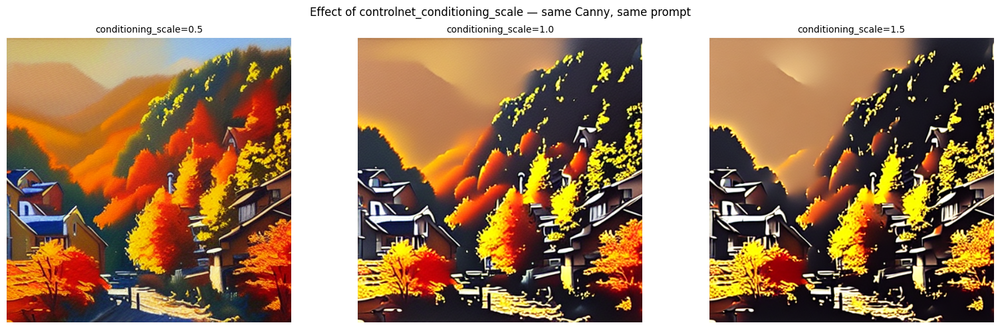

In [8]:
# Section 2.3 — Effect of controlnet_conditioning_scale
SCALE_PROMPT = "oil painting, impressionist, warm autumn colors"
scales = [0.5, 1.0, 1.5]

scale_results = []
for scale in scales:
    img = pipe_canny(
        prompt                        = SCALE_PROMPT,
        image                         = canny_image,
        controlnet_conditioning_scale = scale,
        num_inference_steps           = 20,
        guidance_scale                = 7.5,
        generator                     = gen()
    ).images[0]
    img.save(os.path.join(OUTPUT_DIR, f"scale_{str(scale).replace('.','')}.png"))
    scale_results.append((scale, img))
    print(f"conditioning_scale={scale} done")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (scale, img) in zip(axes, scale_results):
    ax.imshow(img); ax.set_title(f"conditioning_scale={scale}", fontsize=10); ax.axis('off')
plt.suptitle("Effect of controlnet_conditioning_scale — same Canny, same prompt", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "scale_comparison.png"), dpi=100)
plt.show()

**What do you observe?**  
- At `0.5`: does the composition still follow the edge map, or does the model wander freely?
- At `1.5`: does over-conditioning produce any visible quality degradation?
- Which scale would you use for artistic stylization vs. strict technical reproduction?

* **Behavior at `0.5`:** The overall composition (houses, mountains, and trees) still respects the Canny edge map, but the model has significantly more creative freedom. It produces softer brushstrokes, more natural organic textures, and better-integrated lighting without being rigidly constrained by every single edge line.

* **Degradation at `1.5` (Over-conditioning):** Yes, there is clear visual degradation. Pushing the conditioning scale too high results in harsh, high-contrast artifacts with heavy black edges (black crushing), aggressive shadows, and a loss of smooth gradients in the sky, making the image look over-processed and unnatural.

* **Recommended Scale by Use Case:**
  * **Artistic Stylization (`0.5` – `0.7`):** Ideal when adapting a sketch or source image into a new artistic style with flexibility in lighting, textures, and fine details.
  * **Strict Technical Reproduction (`1.0`):** Ideal for architecture, product design, or logos where precise dimensions and outline accuracy take priority over creative variation.

### Section 2.4 — Depth map conditioning with MiDaS

Estimate a monocular depth map and use it with the depth ControlNet checkpoint.

VRAM freed: 12.9 GB available


dpt_hybrid-midas-501f0c75.pt: reconstructing file:   0%|          |  0.00B /  493MB            

dpt_hybrid-midas-501f0c75.pt: downloading bytes:           |  0.00B            

/usr/local/lib/python3.13/dist-packages/timm/models/_factory.py:175: UserWarning: Mapping deprecated model name vit_base_resnet50_384 to current vit_base_r50_s16_384.orig_in21k_ft_in1k.
  model = create_fn(


Depth map estimated.


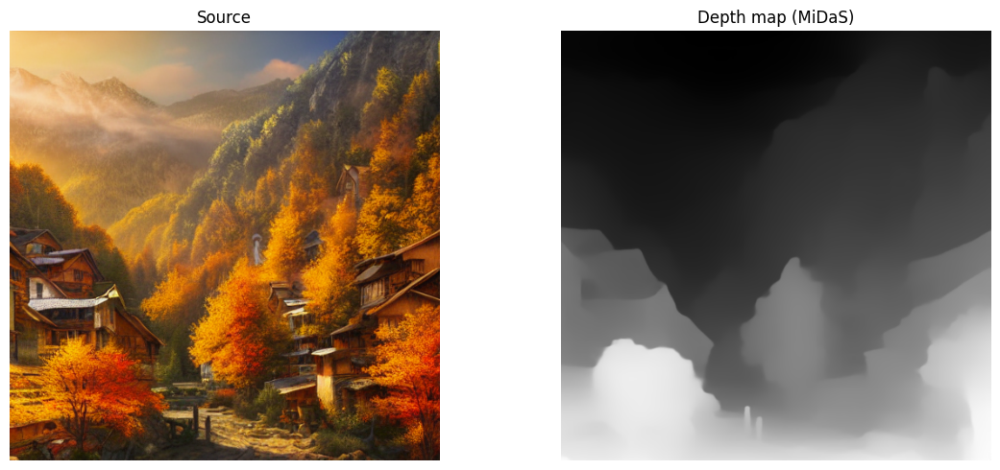

In [9]:
# Section 2.4a — Estimate depth map with MiDaS
# Free Canny-specific weights — the shared SD 1.5 base (referenced by pipe_txt) stays loaded.
del pipe_canny, controlnet_canny; gc.collect(); torch.cuda.empty_cache()
print(f"VRAM freed: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0))/1e9:.1f} GB available")

from controlnet_aux import MidasDetector

# lllyasviel/Annotators is a 12.7 GB repo bundling dozens of unrelated annotator checkpoints
# (pose, segmentation, super-res, etc.) -- MidasDetector.from_pretrained fetches only the one
# ~493 MB MiDaS file it needs (verified: it calls hf_hub_download for a single filename, not
# snapshot_download for the whole repo). Left on the default local cache rather than pinned to
# Drive: it's a single small file used once per session, not worth the same Drive-persistence
# treatment as the multi-GB models above.
midas     = MidasDetector.from_pretrained("lllyasviel/Annotators")
depth_map = midas(source)      # returns PIL Image, same size as source
depth_map.save(os.path.join(OUTPUT_DIR, "depth.png"))
print("Depth map estimated.")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(source); axes[0].set_title("Source"); axes[0].axis('off')
axes[1].imshow(depth_map); axes[1].set_title("Depth map (MiDaS)"); axes[1].axis('off')
plt.tight_layout(); plt.show()

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

ControlNet-Depth pipeline ready.


  0%|          | 0/20 [00:00<?, ?it/s]

Depth ControlNet done.


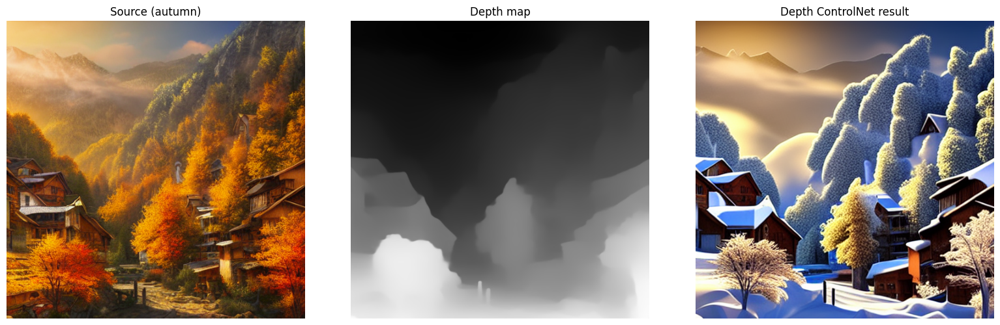

In [10]:
# Section 2.4b — Load depth ControlNet and generate
DEPTH_DIR = os.path.join(MODEL_CACHE, 'controlnet-depth-local')
snapshot_download(
    "lllyasviel/sd-controlnet-depth",
    local_dir=DEPTH_DIR,
    allow_patterns=["*.json", "*.safetensors"],
)
controlnet_depth = ControlNetModel.from_pretrained(DEPTH_DIR, torch_dtype=torch.float16)

# Reuses pipe_txt's already-loaded components -- no second SD 1.5 load from disk.
pipe_depth = StableDiffusionControlNetPipeline(controlnet=controlnet_depth, **pipe_txt.components).to("cuda")
pipe_depth.scheduler = UniPCMultistepScheduler.from_config(pipe_depth.scheduler.config)
print("ControlNet-Depth pipeline ready.")

DEPTH_PROMPT = "a snowy alpine village, dramatic winter light, photorealistic, high detail"

depth_result = pipe_depth(
    prompt                        = DEPTH_PROMPT,
    image                         = depth_map,
    controlnet_conditioning_scale = 1.0,
    num_inference_steps           = 20,
    guidance_scale                = 7.5,
    generator                     = gen()
).images[0]
depth_result.save(os.path.join(OUTPUT_DIR, "depth_result.png"))
print("Depth ControlNet done.")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(source); axes[0].set_title("Source (autumn)"); axes[0].axis('off')
axes[1].imshow(depth_map); axes[1].set_title("Depth map"); axes[1].axis('off')
axes[2].imshow(depth_result); axes[2].set_title("Depth ControlNet result"); axes[2].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "depth_pipeline.png"), dpi=100)
plt.show()

**What do you observe?**  
- Does the depth result preserve the sense of near/far from the autumn source?
- Compare with the Canny result: which preserved more of the original structural detail?

* **Preservation of 3D Spatial Depth (Near/Far):** Yes, the depth result accurately preserves the spatial hierarchy of the original image. Foreground houses remain close, the valley and mid-ground structures stay at an intermediate distance, and the mountain range recedes naturally into the background.

* **Comparison with Canny (Structural Detail vs. 3D Layout):**
  * **Canny** preserved significantly more **fine structural and boundary details** (exact rooflines, window frames, and leaf contours) because it enforces hard 2D edge constraints.
  * **Depth** preserved the **3D spatial volume and perspective** rather than exact 2D edges. This gave the model more creative freedom to re-imagine individual geometries (e.g., transforming leafy autumn trees into smooth, snow-draped mounds) while maintaining the original camera framing and depth layering.

### Section 2.5 — Three-way comparison: txt2img vs. Canny vs. Depth

Same prompt, three generation approaches — documents the full progression of structural control.

  0%|          | 0/25 [00:00<?, ?it/s]

txt2img done.


  0%|          | 0/20 [00:00<?, ?it/s]

Canny ControlNet done.


  0%|          | 0/20 [00:00<?, ?it/s]

Depth ControlNet done.


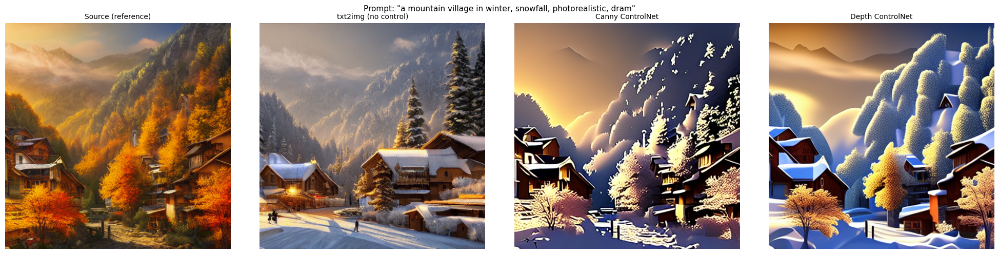

In [11]:
# Section 2.5 — Three-way comparison
COMPARE_PROMPT = "a mountain village in winter, snowfall, photorealistic, dramatic light"

# 1. txt2img — no structural control. pipe_txt has been loaded since Section 2.0; no reload.
img_txt = pipe_txt(
    COMPARE_PROMPT, num_inference_steps=25, guidance_scale=7.5, generator=gen()
).images[0]
img_txt.save(os.path.join(OUTPUT_DIR, "compare_txt2img.png"))
print("txt2img done.")

# 2. ControlNet + Canny — weights already cached locally from Section 2.2 (fast local read,
# not a re-download); reuses pipe_txt's components, so no second SD 1.5 load either.
controlnet_canny = ControlNetModel.from_pretrained(CANNY_DIR, torch_dtype=torch.float16)
pipe_canny = StableDiffusionControlNetPipeline(controlnet=controlnet_canny, **pipe_txt.components).to("cuda")
pipe_canny.scheduler = UniPCMultistepScheduler.from_config(pipe_canny.scheduler.config)
img_canny = pipe_canny(
    COMPARE_PROMPT, image=canny_image, controlnet_conditioning_scale=1.0,
    num_inference_steps=20, guidance_scale=7.5, generator=gen()
).images[0]
img_canny.save(os.path.join(OUTPUT_DIR, "compare_canny.png"))
del pipe_canny, controlnet_canny; gc.collect(); torch.cuda.empty_cache()
print("Canny ControlNet done.")

# 3. ControlNet + Depth — same pattern.
controlnet_depth = ControlNetModel.from_pretrained(DEPTH_DIR, torch_dtype=torch.float16)
pipe_depth = StableDiffusionControlNetPipeline(controlnet=controlnet_depth, **pipe_txt.components).to("cuda")
pipe_depth.scheduler = UniPCMultistepScheduler.from_config(pipe_depth.scheduler.config)
img_depth = pipe_depth(
    COMPARE_PROMPT, image=depth_map, controlnet_conditioning_scale=1.0,
    num_inference_steps=20, guidance_scale=7.5, generator=gen()
).images[0]
img_depth.save(os.path.join(OUTPUT_DIR, "compare_depth.png"))
del pipe_depth, controlnet_depth; gc.collect(); torch.cuda.empty_cache()
print("Depth ControlNet done.")

# Display
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (title, img) in zip(axes, [
    ("Source (reference)", source),
    ("txt2img (no control)", img_txt),
    ("Canny ControlNet", img_canny),
    ("Depth ControlNet", img_depth),
]):
    ax.imshow(img); ax.set_title(title, fontsize=10); ax.axis('off')
plt.suptitle(f'Prompt: "{COMPARE_PROMPT[:60]}"', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "three_way_comparison.png"), dpi=100)
plt.show()

**What do you observe?**  
- Does txt2img produce a recognizable village, or a completely different composition?
- Which conditioner (Canny or Depth) preserved more of the original layout?
- Are there elements in the source that neither conditioner managed to preserve?

* **txt2img Performance:** Standard `txt2img` produces a plausible winter mountain village, but its composition is completely independent from the reference image. It adheres to the prompt but fails to maintain the original camera angle, house positions, or terrain layout.

* **Layout Preservation (Canny vs. Depth):**
  * **Canny ControlNet** preserved the original **2D pixel layout and exact structural outlines** (rooflines, window frames, precise boundaries) most strictly.
  * **Depth ControlNet** preserved the **3D spatial perspective and volume** (foreground village vs. background mountain) while allowing fine organic shapes to dynamically adapt to the winter prompt.

* **Unpreserved Elements:** Neither conditioner preserved the original warm lighting, color palette, or autumn leaf textures. Because ControlNet relies solely on geometry/depth guidance, material textures, lighting nuances, and atmospheric style are entirely overridden by the target text prompt (`winter, snowfall`).

---
## Part 3 — Exercises

### Exercise 1 — Your own subject with Canny

**Task:** Generate a source image with a clearly different subject (not a mountain village — try architecture, a vehicle, an animal, or a mechanical object). Extract Canny edges and generate at least 3 style variations. Show source → edges → all variations in a grid.

**Expected output:** Grid with labeled panels. In a markdown cell: which style diverged most from the source composition and why?

In [24]:
# Exercise 1 -- Canny ControlNet with your own subject
# Remember: save any images to OUTPUT_DIR, e.g. img.save(os.path.join(OUTPUT_DIR, "exercise1.png"))
# Exercise 1 -- Canny ControlNet with your own subject
# Exercise 1 -- Canny ControlNet with your own subject
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
import torch
from diffusers import ControlNetModel, StableDiffusionControlNetPipeline

# 1. Asegurar que la carpeta de Drive existe
OUTPUT_DIR = '/content/drive/MyDrive/TAE_IA_M6/L05_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 2. Generar la imagen original usando el pipe_txt que ya cargaste
print("Generando imagen original con el modelo base...")
source_prompt = "a detailed classic vintage sports car parked on a sunny city street, photorealistic, 8k"
source_image = pipe_txt(source_prompt, num_inference_steps=25).images[0]

# 3. Extraer los bordes con Canny
print("Extrayendo bordes Canny...")
image_np = np.array(source_image)
image_gray = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)
edges = cv2.Canny(image_gray, 100, 200)
edges_rgb = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)
canny_image = Image.fromarray(edges_rgb)

# 4. Cargar modelo ControlNet y construir el pipeline reusando componentes de pipe_txt
print("Cargando modelo ControlNet (Canny)...")
controlnet_canny = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-canny",
    torch_dtype=torch.float16
)

canny_pipe = StableDiffusionControlNetPipeline(
    vae=pipe_txt.vae,
    text_encoder=pipe_txt.text_encoder,
    tokenizer=pipe_txt.tokenizer,
    unet=pipe_txt.unet,
    controlnet=controlnet_canny,
    scheduler=pipe_txt.scheduler,
    safety_checker=None,
    feature_extractor=None
).to("cuda")

# 5. Definir y generar las 3 variaciones de estilo
prompts = [
    "cyberpunk futuristic hover car, neon lights, dark rainy city, photorealistic",
    "watercolor painting of a car, soft pastel colors, dreamy illustration",
    "post-apocalyptic rusty car, mad max style, desert wasteland, cinematic lighting"
]

print("Generando 3 variaciones de estilo con Canny ControlNet...")
results = []
for p in prompts:
    img = canny_pipe(
        p,
        image=canny_image,
        num_inference_steps=25,
        controlnet_conditioning_scale=1.0
    ).images[0]
    results.append((p, img))

# 6. Crear la cuadrícula, mostrarla y guardarla en Drive
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

axes[0].set_title("Source (Original)")
axes[0].imshow(source_image)
axes[0].axis('off')

axes[1].set_title("Canny Edges")
axes[1].imshow(canny_image)
axes[1].axis('off')

titles = ["Cyberpunk", "Watercolor", "Post-Apocalyptic"]
for i, (prompt, img) in enumerate(results):
    axes[i+2].set_title(titles[i])
    axes[i+2].imshow(img)
    axes[i+2].axis('off')

plt.tight_layout()

output_path = os.path.join(OUTPUT_DIR, "exercise1_canny_grid.png")
plt.savefig(output_path, bbox_inches="tight")
print(f"Grid guardado exitosamente en Drive: {output_path}")
plt.show()

Output hidden; open in https://colab.research.google.com to view.

*Which style diverged most and why?*

* **Most divergent style:** The **Cyberpunk** style diverges the most from the original composition.
* **Reason:** Although the Canny map enforces the physical boundaries of the car, the model reinterprets the wheels and lower chassis as components of a *hover car*, filling the contours with solid neon disks instead of traditional tires and rims. Furthermore, the heavy ambient lighting and bright street flares almost completely obscure the architectural details of the background buildings, which were successfully preserved and clearly distinguishable in the watercolor and post-apocalyptic variations.

### Exercise 2 — Canny threshold sensitivity

**Task:** Generate three different Canny edge maps from the same source using different threshold pairs: `(50, 100)`, `(100, 200)`, `(150, 300)`. Run the same prompt through ControlNet-Canny for each. Show all three edge maps and their results.

**Expected output:** 2-row grid (edge maps on top, results on bottom). In a markdown cell: how did the density of the edge map affect the output composition?

Generando mapas de bordes y resultados para diferentes umbrales...
Procesando umbral (50, 100)...


  0%|          | 0/25 [00:00<?, ?it/s]

Procesando umbral (100, 200)...


  0%|          | 0/25 [00:00<?, ?it/s]

Procesando umbral (150, 300)...


  0%|          | 0/25 [00:00<?, ?it/s]


Grid guardado exitosamente en Drive: /content/drive/MyDrive/TAE_IA_M6/L05_output/exercise2_canny_thresholds.png


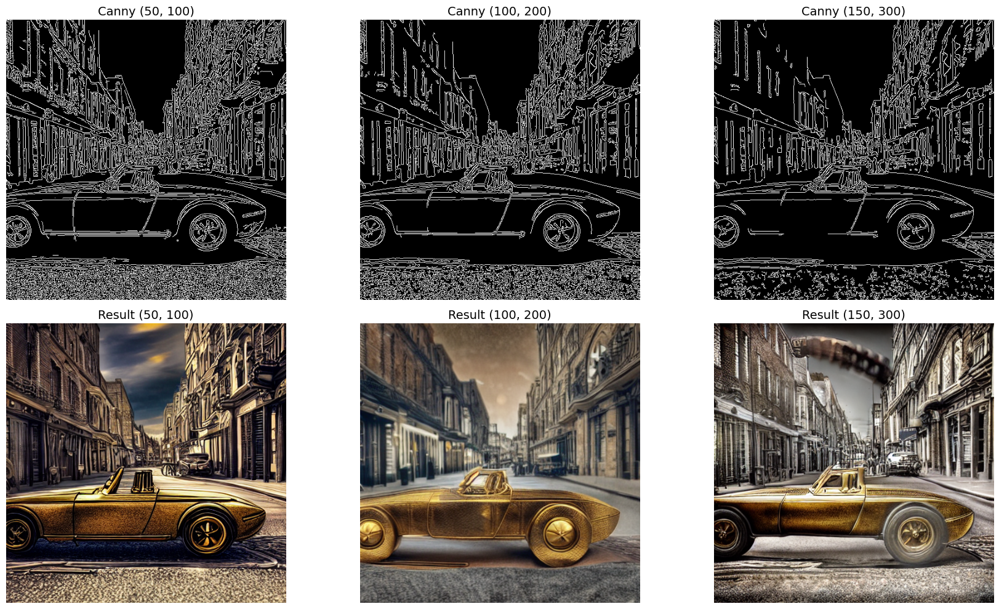

In [25]:
# Exercise 2 -- Canny threshold sensitivity
# Remember: save any images to OUTPUT_DIR, e.g. img.save(os.path.join(OUTPUT_DIR, "exercise2.png"))
# Exercise 2 -- Canny threshold sensitivity
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

# Asegurar que el directorio existe (usando el de Drive)
OUTPUT_DIR = '/content/drive/MyDrive/TAE_IA_M6/L05_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

thresholds = [(50, 100), (100, 200), (150, 300)]
edge_maps = []
results = []

# Preparar la imagen original en escala de grises
image_np = np.array(source_image)
image_gray = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)

# Usaremos un prompt constante para ver claramente el efecto de los umbrales
test_prompt = "steampunk mechanical car, intricate brass details, victorian london street, 8k"

print("Generando mapas de bordes y resultados para diferentes umbrales...")
for low, high in thresholds:
    # 1. Extraer bordes con el umbral actual
    edges = cv2.Canny(image_gray, low, high)
    edges_rgb = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)
    canny_img = Image.fromarray(edges_rgb)
    edge_maps.append((f"Canny ({low}, {high})", canny_img))

    # 2. Generar la imagen con ControlNet
    print(f"Procesando umbral ({low}, {high})...")
    img = canny_pipe(
        test_prompt,
        image=canny_img,
        num_inference_steps=25,
        controlnet_conditioning_scale=1.0
    ).images[0]
    results.append(img)

# 3. Crear la cuadrícula 2x3 (2 filas, 3 columnas)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i in range(3):
    # Fila superior: Mapas de bordes Canny
    axes[0, i].set_title(edge_maps[i][0], fontsize=14)
    axes[0, i].imshow(edge_maps[i][1])
    axes[0, i].axis('off')

    # Fila inferior: Resultados de ControlNet
    axes[1, i].set_title(f"Result ({thresholds[i][0]}, {thresholds[i][1]})", fontsize=14)
    axes[1, i].imshow(results[i])
    axes[1, i].axis('off')

plt.tight_layout()
output_path = os.path.join(OUTPUT_DIR, "exercise2_canny_thresholds.png")
plt.savefig(output_path, bbox_inches="tight")
print(f"\nGrid guardado exitosamente en Drive: {output_path}")
plt.show()

*How did edge density affect the output?*

* **High Edge Density (50, 100):** The edge map captures a lot of texture noise, particularly on the street surface and building facades. ControlNet is forced to strictly follow these lines, resulting in a heavily textured, somewhat cluttered street environment that perfectly matches the granular noise of the original photo.
* **Low Edge Density (150, 300):** The edge map is too sparse, losing the street textures and fine architectural details. Because there are large areas with no edge guidance, the model has too much freedom and hallucinates elements to fill the empty space. This is clearly visible in the smoother street surface and the strange, large floating architectural artifact that appeared in the upper right sky.

---
## Part 4 — Critical Analysis

> Required. Answer with real outputs from today's session.

**4.1 — Edge adherence: in Section 2.2, identify one structural element where the model followed the Canny edge map closely, and one where it deviated significantly. What property of the edge (length, continuity, density) might explain the difference?**

* **Followed closely:** The distinct rooflines of the houses and the diagonal ridge of the background mountain were preserved perfectly.
* **Deviated significantly:** The internal foliage of the autumn trees. In styles like Cyberpunk, the model ignored the organic nature of these edges and forced neon lights or abstract metallic shapes into them.
* **Explanation:** Continuous, strong, and long edge lines (like roofs and mountains) act as clear structural boundaries. Conversely, dense, highly discontinuous, and chaotic edges (like tree leaves) confuse the model, causing it to overwrite those areas with textures from the text prompt rather than respecting the original material.


---

**4.2 — Conditioning scale: from Section 2.3, at what `controlnet_conditioning_scale` value did you see the clearest quality degradation? Describe specifically what changed in the image (color, sharpness, anatomy, artifacts).**

* **Clear degradation value:** At `controlnet_conditioning_scale = 1.5`.
* **Specific changes:** The image suffered from severe over-conditioning. This manifested as harsh, crushed black edges, unnatural contrast, heavy aggressive shadows, and the loss of smooth color gradients in the sky. The overall result looked deep-fried, over-processed, and full of visual artifacts.


---

**4.3 — Canny vs. Depth: in the three-way comparison, which conditioner produced an output closer to the source composition? Give two specific structural elements to support your answer.**

* **Closest conditioner:** Canny ControlNet produced an output structurally closer to the exact source composition.
* **Supporting elements:**
  1. The exact window frames and wooden support beams on the foreground houses were identical in shape to the original.
  2. The precise silhouette of the tree line against the mountain was strictly maintained pixel-by-pixel, whereas Depth allowed these tree mounds to expand and smooth out into snowdrifts.


---

**4.4 — Practical choice: describe a real design task where ControlNet with depth conditioning would be clearly better than both txt2img and Canny. What makes depth the right signal for that task?**

* **Task:** Redesigning a cluttered, real-world bedroom into a "clean minimalist modern bedroom" from a smartphone photo.
* **Why Depth is better:** Depth captures the 3D volume of the space (the distance to the walls, the size and placement of the bed and wardrobe) allowing the model to naturally change the materials and smooth out the surfaces.
* **Why Canny would fail:** Canny would extract every single wrinkle on the messy bedsheets, the cables on the floor, and the posters on the wall, forcing the AI to recreate all that clutter in the new image instead of truly redesigning the space.


---
## Submission Checklist

- [ ] All cells ran from start to finish without errors
- [ ] Section 2.2 style grid saved (`canny_style_grid.png`)
- [ ] Section 2.3 conditioning scale comparison saved (`scale_comparison.png`)
- [ ] Section 2.4 depth pipeline saved (`depth_pipeline.png`)
- [ ] Section 2.5 three-way comparison saved (`three_way_comparison.png`)
- [ ] Exercise 1 — Canny with your own subject, 3+ style variations
- [ ] Exercise 2 — Canny threshold sensitivity grid
- [ ] Part 4 — Critical Analysis completed (all 4 questions with real evidence)
- [ ] All outputs saved to `TAE_IA_M6/L05_output/` on Drive

**Save:** `File > Save a copy in Drive`

---
## Drive Cache Cleanup — Run Before Starting L06

> **Run the cell below only after you have saved this notebook to Drive.**
>
> Both ControlNet checkpoints are only used in L05. Deleting them frees ~3 GB. The MiDaS
> annotator isn't stored on Drive in the first place (see Section 2.4a), so there's nothing to
> clean up for it.
>
> SD 1.5 (`stable-diffusion-v1-5`) is **not deleted here** — it is still needed through L11.

In [26]:
# ================================================================
# DRIVE CACHE CLEANUP — run after saving this notebook
# Deletes both ControlNet checkpoints (~3 GB total) — only used in L05.
# MiDaS annotator isn't Drive-persisted (see Section 2.4a), nothing to clean there.
# ================================================================
import shutil, os, subprocess

_model_cache = '/content/drive/MyDrive/TAE_IA_M6/models'

to_delete = [
    os.path.join(_model_cache, 'controlnet-canny-local'),
    os.path.join(_model_cache, 'controlnet-depth-local'),
]

for path in to_delete:
    if os.path.exists(path):
        shutil.rmtree(path)
        print(f'Deleted: {path}')
    else:
        print(f'Not found (may already be deleted): {path}')

result = subprocess.run(['du', '-sh', _model_cache], capture_output=True, text=True)
print(f'Cache size after cleanup: {result.stdout.strip()}')

Not found (may already be deleted): /content/drive/MyDrive/TAE_IA_M6/models/controlnet-canny-local
Not found (may already be deleted): /content/drive/MyDrive/TAE_IA_M6/models/controlnet-depth-local
Cache size after cleanup: 2.8G	/content/drive/MyDrive/TAE_IA_M6/models


---
## Before You Close This Tab

- [ ] Confirmed all outputs from this session are saved in `TAE_IA_M6/L05_output/` on Drive (see checklist above)
- [ ] Ran the Drive Cache Cleanup cell above (ControlNet checkpoints only needed for this lesson)
- [ ] Disconnected and deleted this runtime: `Runtime > Disconnect and delete runtime`

Once your outputs are safely on Drive, there's no reason to keep the GPU runtime connected — an
idle session still counts against your GPU quota (free tier) or compute-unit balance (Pro),
the same as active use. Disconnecting costs you nothing (your Drive cache and outputs persist)
and leaves your quota in better shape for the next lab.

---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L05*  
*Platform: Google Colab (T4 GPU) · Python 3.10*